# PCA: Actividad práctica: Compresión de imágenes

**Contexto:** Una imagen en escala de grises es una matriz. PCA puede reducir su "dimensionalidad" al encontrar las direcciones (vectores propios) que mejor capturan la estructura de la imagen.

## Procedimiento

1. Cargar `imagen_gris.png` como una matriz **X**.
2. Aplicar PCA a esta matriz para obtener los valores y vectores propios.
3. **Comprimir:** Proyectar la imagen sobre las primeras `k` componentes principales: **Y = X_c V_k**.
4. **Almacenar:** Para la compresión, guardamos la matriz proyectada **Y**, la matriz de componentes **V_k**, y la media.
5. **Reconstruir:** Recuperar una aproximación de la imagen original: **X_reconst = Y V_k^T + media(X)**.

## 1. Cargar librerías y datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

## 2. Cargar `imagen_gris.png` como una matriz X

In [2]:
img = Image.open('imagen_gris.png').convert('L')
X = np.array(img, dtype=float)
print('Matriz X (imagen gris):', X.shape)
media_X = X.mean()
print('Media de X:', media_X)

Matriz X (imagen gris): (512, 512)
Media de X: 124.07119750976562


### Centrar la matriz: X_c = X - media(X)

In [3]:
X_c = X - media_X
print('Forma de X_c:', X_c.shape)

Forma de X_c: (512, 512)


## 3. Aplicar PCA a esta matriz para obtener los valores y vectores propios

In [4]:
# Aplicamos PCA con el máximo número de componentes (minimo entre filas y columnas)
n_components_max = min(X_c.shape)
pca = PCA(n_components=n_components_max)
pca.fit(X_c)
print('Componentes totales:', pca.n_components_)
print('Valores propios (varianza explicada por componente):', np.round(pca.explained_variance_[:5], 2), '...')

Componentes totales: 512
Valores propios (varianza explicada por componente): [225639.82 144094.43  87225.68  68986.26  60335.69] ...


## 4. Comprimir: Proyectar la imagen sobre las primeras `k` componentes principales: Y = X_c V_k

In [5]:
def comprimir(X_c, pca, k):
    V_k = pca.components_[:k, :].T  # vectores propios de las primeras k componentes
    Y = X_c @ V_k                # proyección
    return Y, V_k

k = 50  # ejemplo
Y, V_k = comprimir(X_c, pca, k)
print('Dimensiones de Y (comprimida):', Y.shape)
print('Dimensiones de V_k (componentes):', V_k.shape)

Dimensiones de Y (comprimida): (512, 50)
Dimensiones de V_k (componentes): (512, 50)


## 5. Almacenar: guardamos la matriz proyectada Y, la matriz de componentes V_k, y la media

In [6]:
# En este paso simplemente mostramos qué datos se almacenarían para la compresión
print('Datos almacenados para compresión con k =', k)
print('- Matriz proyectada Y:', Y.shape)
print('- Matriz de componentes V_k:', V_k.shape)
print('- Media de la imagen original:', media_X)

Datos almacenados para compresión con k = 50
- Matriz proyectada Y: (512, 50)
- Matriz de componentes V_k: (512, 50)
- Media de la imagen original: 124.07119750976562


## 6. Reconstruir: Recuperar una aproximación de la imagen original: X_reconst = Y V_k^T + media(X)

In [7]:
def reconstruir(Y, V_k, media_X):
    X_reconst = Y @ V_k.T + media_X
    return X_reconst

X_reconst = reconstruir(Y, V_k, media_X)
print('Dimensiones de X_reconst:', X_reconst.shape)

Dimensiones de X_reconst: (512, 512)


## Tareas

### Tarea 1: Visualizar la imagen reconstruida para diferentes valores de `k` (ej. `k = 1, 5, 20, 50, 100`)

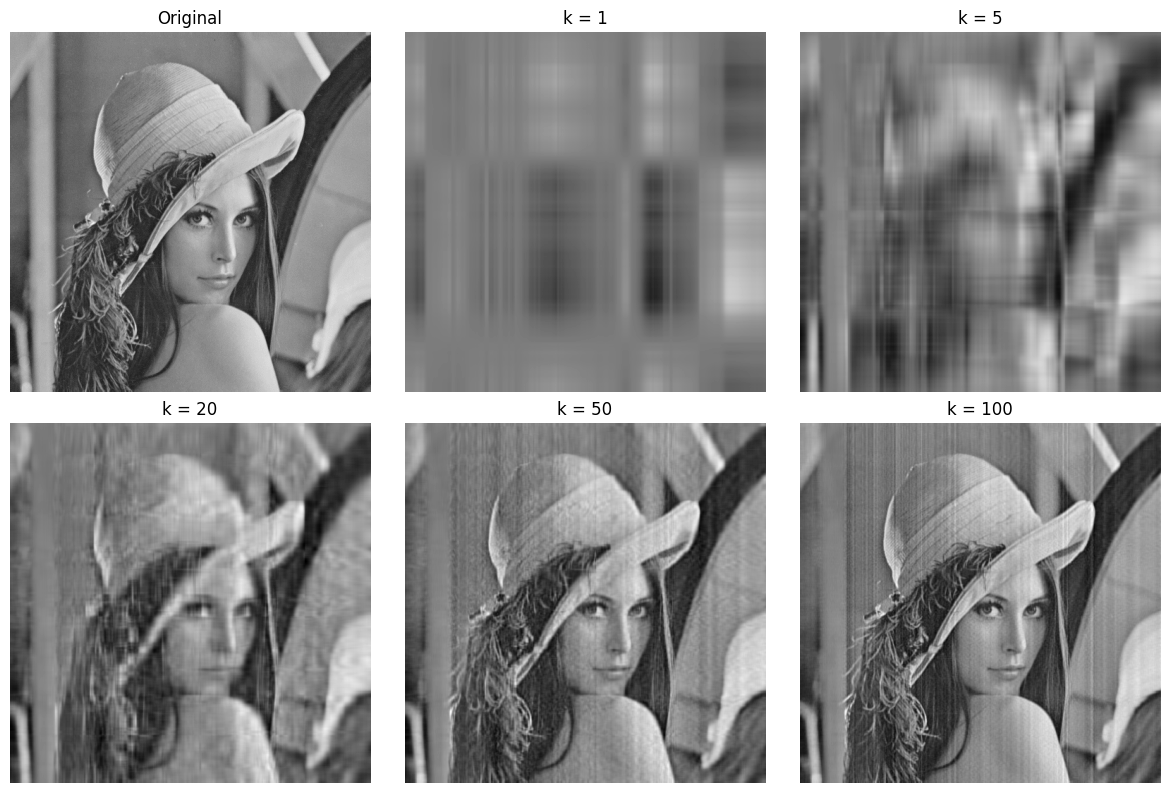

In [8]:
valores_k = [1, 5, 20, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flat

# Mostrar imagen original en el primer panel
axes[0].imshow(X, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, k in enumerate(valores_k):
    Y_k, V_k = comprimir(X_c, pca, k)
    X_recon_k = reconstruir(Y_k, V_k, media_X)
    axes[idx + 1].imshow(X_recon_k, cmap='gray', vmin=0, vmax=255)
    axes[idx + 1].set_title(f'k = {k}')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()

### Tarea 2: Comparar la calidad visual y el nivel de compresión logrado

In [9]:
# Calcular nivel de compresión y error para cada k
print('Comparación de compresión (imagen de', X_c.shape[0], 'x', X_c.shape[1], '):')
print(f'{"k":>5} {"Datos almacenados":>18} {"Compresión aproximada":>25} {"Error cuadrático medio":>25}')
print('-' * 80)

for k in valores_k:
    Y_k, V_k = comprimir(X_c, pca, k)
    X_recon_k = reconstruir(Y_k, V_k, media_X)
    datos_almacenados = Y_k.size + V_k.size + 1  # +1 por la media
    datos_originales = X.size
    compresion_approx = datos_almacenados / datos_originales
    mse = np.mean((X - X_recon_k) ** 2)
    print(f'{k:5d} {datos_almacenados:18d} {compresion_approx:25.4f} {mse:25.2f}')

Comparación de compresión (imagen de 512 x 512 ):
    k  Datos almacenados     Compresión aproximada    Error cuadrático medio
--------------------------------------------------------------------------------
    1               1025                    0.0039                   1826.38
    5               5121                    0.0195                    877.44
   20              20481                    0.0781                    391.82
   50              51201                    0.1953                    246.97
  100             102401                    0.3906                    170.30


## Interpretación de los resultados

In [10]:
print('A medida que aumenta k:')
print('- La imagen reconstruida se acerca más a la original (menor error cuadrático medio).')
print('- Se almacenan más datos, por lo que la compresión aproximada aumenta.')
print('- Con valores pequeños de k (ej. 1, 5) se obtiene una aproximación muy simplificada.')

A medida que aumenta k:
- La imagen reconstruida se acerca más a la original (menor error cuadrático medio).
- Se almacenan más datos, por lo que la compresión aproximada aumenta.
- Con valores pequeños de k (ej. 1, 5) se obtiene una aproximación muy simplificada.
